In [70]:
%load_ext autoreload
%autoreload 2
import pprint
import numpy as np
import matplotlib.pyplot as plt
import utils
from utils import Opportunity, TaskType

# latex 
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Computer Modern Roman']})
rc('text', usetex=True)

pp = pprint.PrettyPrinter()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


0 1 4 1
1 2 6 2
2 2 3 1
3 4 8 1
4 0 7 6
5 0 8 6


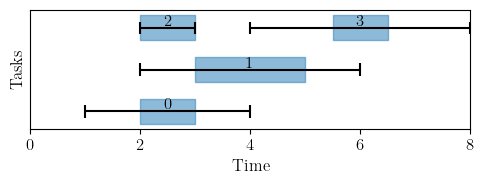

In [105]:
Opportunity.id_count = 0
opportunities = [
    Opportunity(task=1, time_start=1, time_end=4, duration=1),
    Opportunity(task=2, time_start=2, time_end=6, duration=2),
    Opportunity(task=3, time_start=2, time_end=3, duration=1),
    Opportunity(task=4, time_start=4, time_end=8, duration=1),
    Opportunity(
        task=5,
        time_start=0,
        time_end=7,
        duration=6,
        power=1,
        data=0,
        reward=0,
        type=TaskType.SUN_POINTING,
    ),
    Opportunity(
        task=6,
        time_start=0,
        time_end=8,
        duration=6,
        power=-1,
        data=-1,
        reward=0,
        type=TaskType.DOWNLINK,
    ),
]

new_opportunities = []
factor = 1
for opp in opportunities:
    opp.time_start *= factor
    opp.time_end *= factor
    opp.duration *= factor
    new_opportunities.append(opp)
    print(opp.id, opp.time_start, opp.time_end, opp.duration)
opportunities = new_opportunities

slew_times = np.ones((len(opportunities), len(opportunities))) * np.inf
slew_times[0, :] = 1
slew_times[1, :] = 2
slew_times[2, 1:] = 3
slew_times[3, 1:] = 4

plt.figure(figsize=(5, 2))
utils.plot_opportunity_windows(opportunities)
plt.tight_layout()
# text size
rc('font',**{'size': 14})
plt.savefig("figures/tasks.pdf")
plt.show()

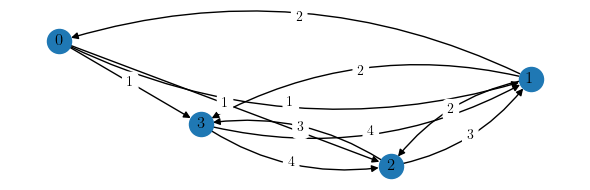

In [72]:
import networkx as nx

np.random.seed(0)

G = nx.DiGraph()
for i, op_1 in enumerate(opportunities):
    for j, op_2 in enumerate(opportunities):
        if i == j:
            continue
        if (
            slew_times[i, j] < np.inf
            and op_1.type == TaskType.USER
            and op_2.type == TaskType.USER
        ):
            G.add_edge(op_1.id, op_2.id, weight=slew_times[i, j])


fig, ax = plt.subplots(figsize=(6, 2))
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_labels(G, pos)

arc_rad = 0.2
curved_edges = [edge for edge in G.edges() if reversed(edge) in G.edges()]
straight_edges = list(set(G.edges()) - set(curved_edges))
nx.draw_networkx_edges(G, pos, edgelist=straight_edges)
nx.draw_networkx_edges(
    G, pos, edgelist=curved_edges, connectionstyle=f"arc3, rad = {arc_rad}"
)

edge_weights = nx.get_edge_attributes(G, "weight")
curved_edge_labels = {edge: int(edge_weights[edge]) for edge in curved_edges}
straight_edge_labels = {edge: int(edge_weights[edge]) for edge in straight_edges}
utils.my_draw_networkx_edge_labels(
    G, pos, ax=ax, edge_labels=curved_edge_labels, rotate=False, rad=arc_rad
)
nx.draw_networkx_edge_labels(
    G, pos, ax=ax, edge_labels=straight_edge_labels, rotate=False
)
plt.axis("off")
plt.tight_layout()

plt.savefig("figures/slew_times.pdf")
plt.show()

In [95]:
import math
import cvxpy as cp

data_min = 0
data_max = 5
data_initial = data_min + 0

power_min = 0
power_max = 5
power_initial = power_max - 1

N_t = max([op.time_end for op in opportunities])
N_t_opt = N_t

In [99]:
N_o = len(opportunities)
lambda_data = 0.5 / data_max
lambda_power = 0.1 / power_max

# Variables
opp_selected = cp.Variable(N_o, boolean=True)
opp_start_times = cp.Variable((N_o, N_t_opt), boolean=True)
opp_times = cp.Variable((N_o, N_t_opt), boolean=True)

# Resources
data_array = np.array([[op.data] for op in opportunities])
power_array = np.array([[op.power] for op in opportunities])
data_var = cp.sum(cp.multiply(opp_times, data_array), axis=0)
power_var = cp.sum(cp.multiply(opp_times, power_array), axis=0)
lower_diag = np.tril(np.ones((N_t_opt, N_t_opt)), k=0)

# Rewards
rewards = np.array([op.reward for op in opportunities])

# Objective
objective = cp.Maximize(
    rewards @ opp_selected
    - lambda_data * cp.max(lower_diag @ data_var)
    - lambda_data * cp.mean(lower_diag @ data_var)
    + lambda_power * cp.min(lower_diag @ power_var)
    + lambda_power * cp.mean(lower_diag @ power_var)
)
# Constraints

constraints = []
for i, opp in enumerate(opportunities):
    # Opportunity times
    ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
    Dt_opp = math.ceil(opp.duration)
    print(opp.id, ts, te, Dt_opp)

    # Valid times
    constraints.append(opp_times[i, ts:te] <= opp_selected[i])
    if ts > 0:
        constraints.append(opp_times[i, :ts] == 0)
    if te < N_t_opt:
        constraints.append(opp_times[i, te:] == 0)

    # Duration constraint
    if opp.type == TaskType.USER:
        # Valid start
        constraints.append(opp_start_times[i, ts : te - Dt_opp + 1] <= opp_selected[i])
        if ts > 0:
            constraints.append(opp_start_times[i, :ts] == 0)
        if te < N_t_opt:
            constraints.append(opp_start_times[i, te - Dt_opp + 1 :] == 0)
        constraints.append(
            cp.sum(opp_start_times[i, ts : te - Dt_opp + 1]) == opp_selected[i]
        )

        # Total duration
        constraints.append(
            cp.sum(opp_times[i, ts:te]) == opp.duration * opp_selected[i]
        )

        for t in range(ts, te - Dt_opp + 1):
            constraints.append(opp_times[i, t : t + Dt_opp] >= opp_start_times[i, t])
            if t > ts:
                constraints.append(opp_times[i, ts:t] <= 1 - opp_start_times[i, t])
            if t + Dt_opp < te:
                constraints.append(
                    opp_times[i, t + Dt_opp : te] <= 1 - opp_start_times[i, t]
                )

    else:
        constraints.append(cp.sum(opp_times[i, :]) >= opp_selected[i])
        constraints.append(cp.sum(opp_times[i, :]) <= N_t_opt * opp_selected[i])
# One task per time
constraints.append(cp.sum(opp_times, axis=0) <= 1)
constraints.append(lower_diag @ data_var + data_initial >= data_min)
constraints.append(lower_diag @ data_var + data_initial <= data_max)
constraints.append(lower_diag @ power_var + power_initial >= power_min)
constraints.append(lower_diag @ power_var + power_initial <= power_max)

# Problem
problem = cp.Problem(objective, constraints)

0 1 4 1
1 2 6 2
2 2 3 1
3 4 8 1
4 0 7 6
5 0 8 6


In [100]:
# Solve
problem.solve(verbose=True)
print("Problem status:", problem.status)
print("Objective value:", problem.value)
print("Selected opportunities:")
print(opp_selected.value.astype(int))
print("Times:")
print(opp_times.value.astype(int))
print("Start times:")
print(opp_start_times.value.astype(int))

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Feb 29 06:00:55 PM: Your problem has 102 variables, 67 constraints, and 0 parameters.
(CVXPY) Feb 29 06:00:55 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 29 06:00:55 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 29 06:00:55 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 29 06:00:55 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 29 06:00:55 PM: Compiling problem (target solver=SCIPY).
(

(CVXPY) Feb 29 06:00:55 PM: Finished problem compilation (took 1.948e-02 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Feb 29 06:00:55 PM: Invoking solver SCIPY  to obtain a solution.
Solver terminated with message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
(CVXPY) Feb 29 06:00:55 PM: Problem status: optimal
(CVXPY) Feb 29 06:00:55 PM: Optimal value: 3.280e+00
(CVXPY) Feb 29 06:00:55 PM: Compilation took 1.948e-02 seconds
(CVXPY) Feb 29 06:00:55 PM: Solver (including time spent in interface) took 4.498e-03 seconds
Proble

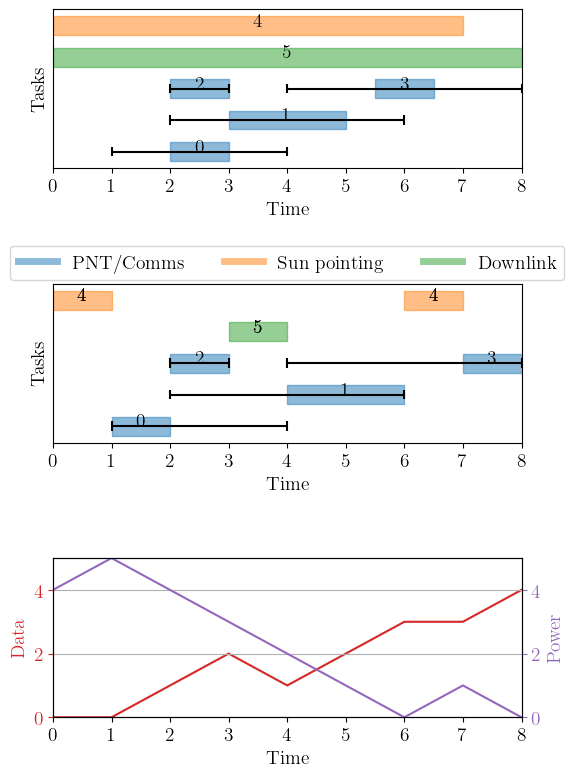

In [108]:
start_end_times = {}
for i, opp in enumerate(opportunities):
    if opp_selected.value[i]:
        tstart, tend = utils.get_start_and_end_indexes(
            np.round(opp_times.value[i, :], 0)
        )
        start_end_times[opp.id] = (tstart, tend)

# Schedule
plt.figure(figsize=(6, 8))
plt.subplot(311)
utils.plot_opportunity_windows(opportunities, plot_all=True, plot_labels=True)
plt.xticks(np.arange(N_t_opt + 1))

plt.subplot(312)
utils.plot_opportunity_windows(
    opportunities, start_end_times, plot_all=True, plot_labels=True
)
plt.xticks(np.arange(N_t_opt + 1))

# Resources
plt.subplot(313)
t_plot = np.arange(N_t_opt + 1)

# Left axis
ax = plt.gca()
color = utils.TABLEAU_COLORS[3]
data_plot = np.append([data_initial], lower_diag @ data_var.value + data_initial)
ax.plot(t_plot, data_plot, label="Data", color=color)
# ax.hlines([data_min, data_max], 0, N_t, color=color, linestyle="--")
ax.set_ylabel("Data", color=color)
ax.tick_params(axis="y", colors=color)
ax.set_ylim(data_min, data_max)
ax.set_xlabel("Time")

# Right axis
ax = ax.twinx()
color = utils.TABLEAU_COLORS[4]
power_plot = np.append([power_initial], lower_diag @ power_var.value + power_initial)
ax.plot(t_plot, power_plot, label="Power", color=color)
# ax.hlines([power_min, power_max], 0, N_t, color=color, linestyle=":")
ax.set_ylabel("Power", color=color)
ax.tick_params(axis="y", colors=color)
ax.set_ylim(power_min, power_max)

ax.set_xlabel("Time")
ax.set_xlim(0, N_t_opt)
ax.grid()

plt.tight_layout()
plt.savefig("figures/schedule.pdf")
plt.show()

## Constraint Checks

In [8]:
opp_times_value = opp_times.value.astype(int)
opp_start_times_value = opp_start_times.value.astype(int)
opp_selected_value = opp_selected.value.astype(int)

In [9]:
# Constraints
for i, opp in enumerate(opportunities):
    constraints = []
    # Opportunity times
    ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
    Dt_opp = math.ceil(opp.duration)

    # Valid times
    constraints.append(opp_times_value[i, ts:te] <= opp_selected_value[i])
    if ts > 0:
        constraints.append(opp_times_value[i, :ts] == 0)
    if te < N_t_opt:
        constraints.append(opp_times_value[i, te:] == 0)

    # Duration constraint
    if opp.type == TaskType.USER:
        # Valid start
        constraints.append(
            opp_start_times_value[i, ts : te - Dt_opp + 1] <= opp_selected_value[i]
        )
        if ts > 0:
            constraints.append(opp_start_times_value[i, :ts] == 0)
        if te < N_t_opt:
            constraints.append(opp_start_times_value[i, te - Dt_opp + 1 :] == 0)
        constraints.append(
            np.sum(opp_start_times_value[i, ts : te - Dt_opp + 1])
            == opp_selected_value[i]
        )

        # Total duration
        constraints.append(
            np.sum(opp_times_value[i, ts:te]) == opp.duration * opp_selected_value[i]
        )

        for t in range(ts, te - Dt_opp + 1):
            constraints.append(
                opp_times_value[i, t : t + Dt_opp] >= opp_start_times_value[i, t]
            )
            if t > ts:
                constraints.append(
                    opp_times_value[i, ts:t] <= 1 - opp_start_times_value[i, t]
                )
            if t + Dt_opp < te:
                constraints.append(
                    opp_times_value[i, t + Dt_opp : te]
                    <= 1 - opp_start_times_value[i, t]
                )

    else:
        constraints.append(np.sum(opp_times_value[i, :]) >= opp_selected_value[i])
        constraints.append(
            np.sum(opp_times_value[i, :]) <= N_t_opt * opp_selected_value[i]
        )
        
    valid = np.min([np.min(c) for c in constraints])
    if not valid:
        print(f"Constraint {i} not valid")
        pp.pprint(constraints)
# One task per time
constraints = []
data_var = np.sum(np.multiply(opp_times_value, data_array), axis=0)
power_var = np.sum(np.multiply(opp_times_value, power_array), axis=0)
constraints.append(np.sum(opp_times_value, axis=0) <= 1)
constraints.append(lower_diag @ data_var + data_initial >= data_min)
constraints.append(lower_diag @ data_var + data_initial <= data_max)
constraints.append(lower_diag @ power_var + power_initial >= power_min)
constraints.append(lower_diag @ power_var + power_initial <= power_max)

valid = np.min([np.min(c) for c in constraints])
if not valid:
    print("Constraints not valid")
    print(constraints)
    print(np.min([np.min(c) for c in constraints]))


In [10]:
i = 3
opp = opportunities[i]
print(opp.id)
ts, te = math.floor(opp.time_start), math.ceil(opp.time_end)
Dt_opp = math.ceil(opp.duration)
print(ts, te, Dt_opp)
print(opp_times.value[i, ts:te])
print(opp_selected.value[i])
print(opp_start_times.value[i, ts : te - Dt_opp + 1])

3
12 24 3
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
1.0
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
